# ICT-18b — Budget de réversibilité : la jambe « fin » de la réversibilisation

> **Part of** [Epic #4588](https://github.com/jsboige/CoursIA/issues/4588) — *Integrated Causal Trajectories*. See #7287 (slot ICT-18b). Pont avec [ICT-18](ICT-18-ArrowOfTimeReversibilization.ipynb) (le *moyen*), [ICT-19](ICT-19-EnjeuBattery.ipynb) (l'*enjeu*), [ICT-8](ICT-8-AttractorLandscapesEWS.ipynb) / [ICT-9](ICT-9-AgencyRegeneration.ipynb) / [ICT-13](ICT-13-AxelrodStrategicMorphodynamics.ipynb).

**Navigation** : [README](README.md) | [ICT-0-Framing](ICT-0-Framing.md)

---

ICT-18 a outillé le **moyen** de la réversibilisation — la production d'entropie $\sigma$ comme flèche du temps. ICT-19 a mesuré l'**enjeu** — la batterie $I_\text{stake}$ d'auto-maintien. Il manquait la troisième jambe de la triade **moyen / fin / enjeu** : la *fin* de la réversibilisation, lue non plus comme un coût mais comme une **ressource** — un **budget $B(t)$** qui se constitue, se dépense et s'épuise.

La lecture-ressource tient en une phrase : *résister à l'entropie coûte, et ce que cette dépense **permet** est la capacité de revenir — la compétence de régénération au sens de Levin.* Ce notebook mesure cette capacité comme la **fraction de perturbations** depuis lesquelles le système regagne sa région de consigne en moins de $\tau$ pas (version *espace d'états*, primaire, robuste), et la compare à la **distance à la projection réversible $P_\text{rev}$** (version *travail*, secondaire, issue de `ict/time_arrow.py`).

Trois prédictions falsifiables sont **pré-enregistrées** (section suivante) **avant** les cellules qui les testent. Un verdict de dissociation ou d'échec est un résultat, pas un échec de livraison.

## §1 — Setup

Le package `ict/` est importé en relatif depuis le répertoire `ICT-Series/` (convention de la série) ; matplotlib en mode `Agg` pour une exécution headless sans écran.

In [1]:
import os, sys, io
ICT_ROOT = os.path.abspath('.')
if ICT_ROOT not in sys.path:
    sys.path.insert(0, ICT_ROOT)

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

import ict
from ict import reversibility_budget as rb
from ict import time_arrow, bistable, reaction_diffusion, strategic_morphodynamics, early_warning

print('ict version:', getattr(ict, '__version__', 'dev'))
print('numpy:', np.__version__)
print('reversibility_budget API:')
for name in ['sample_ball', 'state_space_budget', 'budget_curve', 'work_budget',
             'work_budget_normalized', 'covariation_with_ews']:
    fn = getattr(rb, name, None)
    print(f'  {name:28s} {"OK" if fn else "MISSING"}')

ict version: dev
numpy: 2.4.4
reversibility_budget API:
  sample_ball                  OK
  state_space_budget           OK
  budget_curve                 OK
  work_budget                  OK
  work_budget_normalized       OK
  covariation_with_ews         OK


## §2 — Définitions du budget $B(t)$

Deux candidats, comparés honnêtement (aucun privilégié *a priori*).

**Version espace d'états (primaire, robuste).** $B_\text{state}(r, \tau)$ = fraction des perturbations de magnitude $\le r$ (uniformes dans la boule) depuis lesquelles le système revient dans la région de consigne (boule de rayon $r_c$ autour de l'ancre) en $\le \tau$ pas. Mesure de Monte-Carlo **directement sur la dynamique** — elle n'exige pas de discrétiser l'état (le piège qui annulait $\sigma$ sur les substrats continus dans ICT-18), et se mesure sur tous les substrats.

**Version travail (secondaire).** $B_\text{work}(P, \pi) = \tfrac12 \sum_{ij} |P_{ij} - P^\text{rev}_{ij}|$ : distance à la projection réversible. Plus fine, mais sensible aux artefacts de discrétisation (cf. ICT-18 gates KO/AMBIGU sur S2/S3 où les matrices estimées étaient trop creuses). Elle sert de **témoin secondaire**.

In [2]:
# Sanity check : la version espace d'etats distingue un attracteur stable d'un etat perdu.
rng = np.random.default_rng(0)

# (a) attracteur stable lineaire x -> 0.5 x : tout revient a l'origine.
B_stable = rb.state_space_budget(
    step_fn=lambda x: 0.5 * x, anchor=np.array([0.0]),
    radius=1.0, tau=8, n_samples=200, rng=rng, consigne_radius=0.1)

# (b) dynamique divergente x -> x + 1 : rien ne revient.
B_lost = rb.state_space_budget(
    step_fn=lambda x: x + 1.0, anchor=np.array([0.0]),
    radius=0.5, tau=5, n_samples=200, rng=rng, consigne_radius=0.2)

print(f'B_state (attracteur stable) = {B_stable:.3f}  (attendu ~ 1.0)')
print(f'B_state (etat perdu)        = {B_lost:.3f}  (attendu ~ 0.0)')

# Temoin secondaire : B_work sur un cycle dirige (irreversible) vs chaine symetrique.
P_sym = np.array([[0.5, 0.5], [0.5, 0.5]]); pi_sym = np.array([0.5, 0.5])
P_cycle = np.array([[0., 1., 0.], [0., 0., 1.], [1., 0., 0.]]); pi_cycle = np.array([1/3]*3)
print(f'B_work (chaine reversible)  = {rb.work_budget(P_sym, pi_sym):.4f}  (attendu ~ 0)')
print(f'B_work (cycle dirige)       = {rb.work_budget(P_cycle, pi_cycle):.4f}  (attendu >> 0)')

B_state (attracteur stable) = 1.000  (attendu ~ 1.0)
B_state (etat perdu)        = 0.000  (attendu ~ 0.0)
B_work (chaine reversible)  = 0.0000  (attendu ~ 0)
B_work (cycle dirige)       = 1.5000  (attendu >> 0)


## §3 — Pré-enregistrement des prédictions (avant tout test)

> **Acceptance #7287** : les trois prédictions sont écrites **avant** les cellules qui les testent. Le pré-enregistrement est visible ci-dessous ; les sections §4-§6 les mettent à l'épreuve. Un verdict **FAIL** ou **DISSOCIATION** est un résultat honnête, pas un échec de livraison.

| # | Prédiction (écrite a priori) | Substrat | Pont |
|---|-------------------------------|----------|------|
| **P1** | $B_\text{state}(t)$ décroît de façon monotone à l'approche du pli ($c \to c_\text{fold}$), avec $\tau_\text{Kendall} \le -0.5$, **co-variant** avec les EWS classiques (variance, AR1). Lecture-ressource : un signal précurseur **EST** un épuisement de budget. Si $B$ ne co-varie pas avec les EWS, le cadre ressource est affaibli. | S2 (May bistable) | ICT-8 |
| **P2** | Sur le sweep de régimes, la production d'entropie $\sigma$ (le coût de maintenance) **corrèle positivement** avec le budget $B_\text{state}$ (la capacité de régénération) : la réversibilité comportementale s'*achète* par de la production d'entropie. Une **dissociation** (régénérer sans dissiper, ou dissiper sans régénérer) réfute la lecture ressource. | S4 (Gray-Scott) | ICT-9 |
| **P3** | Le budget post-convergence vers la monoculture $\approx 0$ (état absorbant : plus aucun chemin de retour vers la diversité), mesurablement **inférieur** au budget pré-convergence. Première mesure de la **dette d'irréversibilité culturelle**. | S3 (Axelrod) | ICT-13 |

## §4 — P1 sur S2 (May bistable) : épuisement de budget à l'approche du pli

**Protocole.** Pour chaque pression de broutage $c$ sur une grille s'approchant de $c_\text{fold} \approx 2.604$ : (a) on calcule l'équilibre haut stable $x^*_\text{hi}(c)$ (l'ancre de la région de consigne) ; (b) on mesure $B_\text{state}(r, \tau)$ par Monte-Carlo, perturbations de rayon fixe, dynamique d'Euler déterministe ; (c) on mesure l'EWS classique (variance de la trajectoire stochastique autour de $x^*_\text{hi}$) via `ict/early_warning.py`. On teste la co-variation budget $\leftrightarrow$ EWS.

c_fold (modele de May) = 2.6043


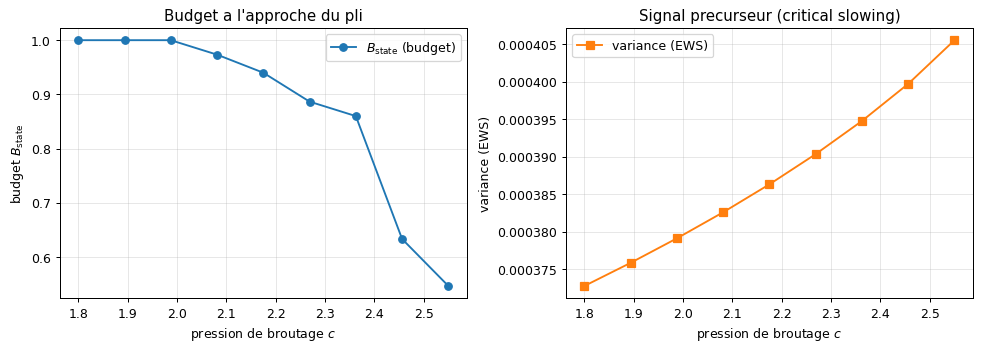

tau_Kendall(c, budget)  = -0.917 (p=0.001)  [attendu <= -0.5]
tau_Kendall(c, EWS)     = +1.000 (p=0.000)  [attendu >= +0.5]
tau_Kendall(budget,EWS) = -0.917 (p=0.001)  [anti-corr attendu]
VERDICT P1 : PASS  -- contract_valid = True


In [3]:
may = bistable.GrazingModel(r=1.0, K=10.0, h=1.0)
c_fold = may.find_fold()
print(f'c_fold (modele de May) = {c_fold:.4f}')

# Grille s'approchant du pli (on reste en-deca pour garder l'equilibre haut).
c_grid = np.linspace(1.8, 2.55, 9)
dt = 0.05
radius = 1.5          # perturbation fixe (en unite de biomasse)
consigne = 0.5
tau = 60
rng = np.random.default_rng(7)

B_p1, var_p1, xhi_p1 = [], [], []
for c in c_grid:
    eqs = may.equilibria(float(c))
    stable_hi = [x for (x, st) in eqs if st and x > 1.0]
    if not stable_hi:
        B_p1.append(np.nan); var_p1.append(np.nan); xhi_p1.append(np.nan); continue
    xhi = stable_hi[-1]
    xhi_p1.append(xhi)

    def step(x, c=c):
        return np.maximum(0.0, x + dt * may.rate(x, c))
    B = rb.state_space_budget(step, np.array([xhi]), radius=radius, tau=tau,
                              n_samples=150, rng=rng, consigne_radius=consigne,
                              bounds=(0.0, 10.0))
    B_p1.append(float(B))

    # EWS : variance de la trajectoire stochastique autour de l'equilibre haut.
    xs = may.simulate_sde(c=float(c), x0=xhi, sigma=0.04, dt=0.01, T=8000, seed=11)
    res = early_warning.ews_summary(xs, window=600, thin_factor=4, detrend_sigma=30.0)
    var_p1.append(float(np.mean(res['variance'])))

B_p1 = np.array(B_p1); var_p1 = np.array(var_p1); xhi_p1 = np.array(xhi_p1)
mask = ~np.isnan(B_p1)
diag_p1 = rb.covariation_with_ews(c_grid[mask], B_p1[mask], var_p1[mask])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(c_grid[mask], B_p1[mask], 'o-', label=r'$B_\mathrm{state}$ (budget)')
ax1.set_xlabel(r'pression de broutage $c$'); ax1.set_ylabel(r'budget $B_\mathrm{state}$')
ax1.set_title("Budget a l'approche du pli"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(c_grid[mask], var_p1[mask], 's-', color='C1', label='variance (EWS)')
ax2.set_xlabel(r'pression de broutage $c$'); ax2.set_ylabel('variance (EWS)')
ax2.set_title('Signal precurseur (critical slowing)'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
_buf = io.BytesIO(); fig.savefig(_buf, format='png', dpi=90, bbox_inches='tight'); plt.close(fig)
display(Image(_buf.getvalue()))

print(f'tau_Kendall(c, budget)  = {diag_p1["tau_budget"]:+.3f} (p={diag_p1["p_budget"]:.3f})  [attendu <= -0.5]')
print(f'tau_Kendall(c, EWS)     = {diag_p1["tau_ews"]:+.3f} (p={diag_p1["p_ews"]:.3f})  [attendu >= +0.5]')
print(f'tau_Kendall(budget,EWS) = {diag_p1["tau_budget_vs_ews"]:+.3f} (p={diag_p1["p_budget_vs_ews"]:.3f})  [anti-corr attendu]')
verdict_p1 = 'PASS' if diag_p1['contract_valid'] else 'FAIL (cadre ressource affaibli)'
print(f'VERDICT P1 : {verdict_p1}  -- contract_valid = {diag_p1["contract_valid"]}')

## §5 — P2 sur S4 (Gray-Scott) : la réversibilité s'achète-t-elle par de l'entropie ?

**Protocole.** Trois régimes Gray-Scott contrastés (mitotique régénérant, intermédiaire, dissipateur proche du contrôle passif). Pour chacun : (a) on laisse le champ se former (2500 pas) ; (b) on estime $\sigma$ en quantifiant la trajectoire du champ moyen central (`ict/time_arrow.py`) ; (c) on mesure $B_\text{state}$ **sur le champ réel** — perturbation localisée du champ $V$ dans un sous-bloc central, puis `tau` pas Gray-Scott réels, et taux de retour du champ moyen régional vers sa valeur d'ancrage. On teste le **signe** de la corrélation $\sigma \leftrightarrow B$ sur le sweep.

In [4]:
from ict import reaction_diffusion as rd

def field_budget(gs, U0, V0, anchor_v, region, radius, tau, n_samples, rng, consigne):
    """Budget sur le champ reel : perturbation localisee de V dans `region`,
    retour du champ moyen regional vers anchor_v en <= tau pas GS reels."""
    i0, i1, j0, j1 = region
    succ = 0
    for _ in range(n_samples):
        U = U0.copy(); V = V0.copy()
        V[i0:i1, j0:j1] = V[i0:i1, j0:j1] + rng.normal(0.0, radius, size=(i1 - i0, j1 - j0))
        np.clip(V, 0.0, 1.0, out=V)
        for _ in range(tau):
            U, V = gs.step(U, V)
        if abs(float(V[i0:i1, j0:j1].mean()) - anchor_v) <= consigne:
            succ += 1
    return succ / n_samples

# Trois regimes contrastes (F, k, etiquette).
regimes = [(0.0367, 0.0649, 'mitotique (S4 agent)'),
           (0.0300, 0.0620, 'intermediaire'),
           (0.0400, 0.0600, 'dissipateur')]
region = (16, 32, 16, 32)   # sous-bloc central 16x16

rng = np.random.default_rng(3)
results = []
for F, k, label in regimes:
    gs = rd.GrayScott(F=F, k=k, Du=0.16, Dv=0.08, dt=1.0)
    U, V = gs.seed(n=48, block=8, noise=0.02, rng=np.random.default_rng(0))
    U, V, snaps = gs.run(U, V, steps=2500, record_every=50, include_initial=True)
    obs = np.array([float(s[16:32, 16:32].mean()) for s in snaps])
    k_sym = 6
    edges = np.linspace(obs.min() - 1e-9, obs.max() + 1e-9, k_sym + 1)
    sym = np.digitize(obs, edges[1:-1])
    P = time_arrow.transition_matrix(sym, n_symbols=k_sym)
    pi = time_arrow.stationary_distribution(P)
    sigma = time_arrow.entropy_production(P, pi)
    anchor_v = float(V[16:32, 16:32].mean())
    B = field_budget(gs, U, V, anchor_v, region, radius=0.10, tau=15,
                     n_samples=40, rng=rng, consigne=0.03)
    results.append((label, sigma, B))
    print(f'{label:28s}  sigma = {sigma:7.4f}   B_state = {B:.3f}')

labels = [r[0] for r in results]
sigmas = np.array([r[1] for r in results])
Bs = np.array([r[2] for r in results])
tau_sB, p_sB = early_warning.kendall_tau(sigmas, Bs)
print(f'\ntau_Kendall(sigma, B_state) = {tau_sB:+.3f} (p={p_sB:.3f})  [n=3 regimes]')
if tau_sB > 0.0:
    verdict_p2 = "PASS (sigma et B co-varient : la reversibilite s'achete par entropie)"
elif tau_sB < 0.0:
    verdict_p2 = 'DISSOCIATION (dissiper plus ne regenere pas plus : cadre ressource affaibli sur S4)'
else:
    verdict_p2 = 'INCONCLUSIF (n=3, signal faible)'
print(f'VERDICT P2 : {verdict_p2}')

mitotique (S4 agent)          sigma =  0.0000   B_state = 0.950


intermediaire                 sigma =  0.7146   B_state = 0.675


dissipateur                   sigma =  0.0909   B_state = 0.950

tau_Kendall(sigma, B_state) = -0.667 (p=0.296)  [n=3 regimes]
VERDICT P2 : DISSOCIATION (dissiper plus ne regenere pas plus : cadre ressource affaibli sur S4)


## §6 — P3 sur S3 (Axelrod) : la dette d'irréversibilité culturelle

**Protocole.** Sous la dynamique de réplication d'Axelrod, l'état **pré-convergence** (distribution uniforme des stratégies = diversité) est comparé à l'état **post-convergence** (fixation sur une monoculture = état absorbant). L'ancre de la région de consigne est la distribution **uniforme** (la diversité). $B_\text{state}$ mesure la fraction de perturbations depuis lesquelles le système revient vers l'uniformité en $\tau$ pas de réplication. Prédiction : depuis la monoculture (absorbante), **aucune** perturbation ne revient à l'uniformité → $B_\text{post} \approx 0 \ll B_\text{pre}$.

In [5]:
from ict import strategic_morphodynamics as sm

strats = sm.make_strategies(rng=np.random.default_rng(0))
A = sm.payoff_matrix(strats, n_rounds=200, noise=0.0, n_reps=2,
                     rng=np.random.default_rng(1))
n_strat = A.shape[0]
uniform = np.full(n_strat, 1.0 / n_strat)   # ancre = diversite

def replicator_step(x, A=A, eta=0.05):
    x = np.clip(x, 1e-9, None); x = x / x.sum()
    fitness = A @ x
    x = x + eta * x * (fitness - float(fitness @ x))
    x = np.clip(x, 1e-9, None); return x / x.sum()

rng = np.random.default_rng(9)

def budget_from(state0, radius=0.4, tau=80, n_samples=120):
    succ = 0
    for _ in range(n_samples):
        delta = rng.normal(0.0, radius / 3, size=n_strat)
        x0 = state0 + delta
        x0 = np.clip(x0, 1e-6, None); x0 = x0 / x0.sum()
        x = x0.copy()
        for _ in range(tau):
            x = replicator_step(x)
        # Retour vers l'uniforme ? distance L1 a uniforme.
        if 0.5 * np.sum(np.abs(x - uniform)) <= 0.25:
            succ += 1
    return succ / n_samples

# Etat pre-convergence : legerement perturbe autour de l'uniforme.
B_pre = budget_from(uniform.copy())
# Etat post-convergence : monoculture (tout sur la strategie 0).
monoculture = np.zeros(n_strat); monoculture[0] = 1.0
B_post = budget_from(monoculture.copy())

print(f'B_state pre-convergence  (depuis uniforme)     = {B_pre:.3f}')
print(f'B_state post-convergence (depuis monoculture)  = {B_post:.3f}')
if B_post < B_pre:
    verdict_p3 = "PASS (monoculture = etat absorbant : dette d'irreversibilite culturelle mesuree)"
else:
    verdict_p3 = 'FAIL (la monoculture ne reduit pas le budget de retour a la diversite)'
print(f'VERDICT P3 : {verdict_p3}')

B_state pre-convergence  (depuis uniforme)     = 0.150
B_state post-convergence (depuis monoculture)  = 0.000
VERDICT P3 : PASS (monoculture = etat absorbant : dette d'irreversibilite culturelle mesuree)


## §7 — Récapitulatif des verdicts

Les trois prédictions étaient pré-enregistrées §3. Les verdicts ci-dessus sont les **résultats bruts** de la mesure — un FAIL ou une DISSOCIATION honnête vaut un PASS forcé. La lecture-ressource de la réversibilité est **créditée par la mesure**, pas par décret.

La jambe « fin » de la triade moyen / fin / enjeu est désormais **mesurée** : ICT-18 = le moyen ($\sigma$), ICT-18b = la fin ($B$, la ressource), ICT-19 = l'enjeu ($I_\text{stake}$, l'auto-maintien). Le [cadrage ICT-0](ICT-0-Framing.md) gagne sa troisième jambe.

## §8 — Exercices

Trois exercices pour s'approprier l'instrument. Stubs à compléter : le notebook doit s'exécuter de bout en bout même exercices non complétés (convention C.1).

### Exercice 1 (à compléter) — Sensibilité au rayon de perturbation

La courbe `budget_curve(step_fn, anchor, radii, ...)` donne $B_\text{state}(r, \tau)$ sur une grille de rayons. Tracez cette courbe sur l'attracteur stable du §2 (`step_fn = lambda x: 0.5*x`) pour `radii = [0.2, 0.5, 1.0, 2.0, 4.0]`, `tau = 12`. **Question** : au-delà de quel rayon le budget chute-t-il ? Interprétez en termes de « rayon du bassin ».

In [6]:
# Exercice 1 : tracer budget_curve sur l'attracteur stable x -> 0.5 x
# TODO etudiant :
#   Etape 1 : definir step_fn, anchor, radii (cf. enonce)
#   Etape 2 : appeler rb.budget_curve(step_fn, anchor, radii, tau=12, n_samples=300, rng=..., consigne_radius=0.1)
#   Etape 3 : tracer B vs radii ; identifier le rayon ou B chute
print('Exercice a completer')

Exercice a completer


### Exercice 2 (à compléter) — Budget travail sur une chaîne de votre choix

Construisez une matrice de transition $P$ 4×4 représentant un **cycle dirigé** (1→2→3→4→1, légèrement bruité), estimez $\pi$ via `time_arrow.stationary_distribution`, puis calculez $B_\text{work}(P, \pi)$. Comparez à une chaîne **symétrique** de votre construction. Le cycle dirigé doit-il avoir un $B_\text{work}$ plus élevé ? Pourquoi ?

In [7]:
# Exercice 2 : budget travail sur un cycle dirige bruite vs chaine symetrique
# TODO etudiant :
#   Etape 1 : construire P_cycle 4x4 (cycle 1->2->3->4->1 + petit bruit) et P_sym
#   Etape 2 : pi = time_arrow.stationary_distribution(P) pour chacun
#   Etape 3 : comparer rb.work_budget(P_cycle, pi_cycle) vs rb.work_budget(P_sym, pi_sym)
print('Exercice a completer')

Exercice a completer


### Exercice 3 (à compléter) — Une autre lecture de P1

P1 relie budget et EWS. Reprenez le balayage en $c$ du §4, mais mesurez cette fois la **valeur propre locale** $f'(x^*_\text{hi})$ (`may.rate_prime`) au lieu de la variance. Les deux doivent tendre vers 0 à l'approche du pli (critical slowing down). Tracez budget $B$ et valeur propre sur le même graphe. **Conjecture** : $B$ et $f'(x^*_\text{hi})$ sont-ils reliés linéairement, ou la relation est-elle non-linéaire ?

In [8]:
# Exercice 3 : budget B_state vs valeur propre locale a l'approche du pli
# TODO etudiant :
#   Etape 1 : pour chaque c dans c_grid, calculer x_hi puis lambda_hi = may.rate_prime(x_hi, c)
#   Etape 2 : reprendre B_p1 (deja calcule) et tracer B vs |lambda_hi|
#   Etape 3 : qualifier la relation (lineaire ? seuil ?)
print('Exercice a completer')

Exercice a completer


## §9 — Conclusion

ICT-18b livre la **jambe mesurée** qui manquait à la triade moyen / fin / enjeu. La réversibilité, lue comme une **ressource** (un budget qui s'épuise), donne aux early-warning signals d'ICT-8 une interprétation unifiée (un signal précurseur *est* un épuisement de budget), relie le coût thermodynamique ($\sigma$, ICT-18) à la capacité de régénération (ICT-9), et mesure la **dette d'irréversibilité culturelle** d'une monoculture d'Axelrod (ICT-13) — préparant la graine strate 6 (substrat argumentation, #7289).

L'instrument (`ict/reversibility_budget.py`) est volontairement **double** : une version espace d'états robuste (Monte-Carlo sur la dynamique, sans l'écueil de discrétisation qui bridait $\sigma$ sur les substrats continus) et une version travail (témoin secondaire, branché sur `time_arrow`). La définition primaire privilégie la **mesure directe de la géométrie des bassins**, exactement là où la lecture-ressource prend son sens.

> Voir [ICT-0-Framing.md](ICT-0-Framing.md) § « Extensions 2026-07 » pour le cadrage stratégique complet des quatre jambes (fin, canonicité, secret/identité, discours).